In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import os
# os.chdir('/content/drive/MyDrive/Project2/')

In [3]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import tensorflow as tf
tf.__version__

'2.15.0'

In [6]:
import keras
keras.__version__

'2.15.0'

In [7]:
import cv2
import math
import time
import shutil
import random
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt

In [8]:
# !pip install keras-cv -q
!pip install tensorflow_addons -q

In [9]:
import keras_cv
import tensorflow_datasets as tfds

tfds.disable_progress_bar()
tf.keras.utils.set_random_seed(42)

Using TensorFlow backend


In [10]:
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [11]:
keras.saving.get_custom_objects().clear()
tf.keras.backend.clear_session() ## to clear other sessions in the environment
# tf.config.optimizer.set_jit(True) ## enabling XLA
# policy = tf.keras.mixed_precision.Policy('mixed_float16')
# tf.keras.mixed_precision.set_global_policy(policy)

In [12]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [13]:
!nvidia-smi

Fri Aug 22 18:18:41 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.64.03              Driver Version: 575.64.03      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA TITAN Xp                Off |   00000000:03:00.0  On |                  N/A |
| 53%   77C    P5             20W /  250W |     417MiB /  12288MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Variables

In [14]:
end = '_HAM10000_classification_AutoAugment'
destination='Results/classification2/1.HAM10000/Fold1/'

In [15]:
tempfolder="temp_HAM10000_AutoAugment"
isExist = os.path.exists(tempfolder)
if not isExist:
    os.makedirs(tempfolder)

data_root='Datasets/1.HAM10000/classification/fold1/'
output_path="./"+tempfolder+"/"

train_dir=data_root+"train/"
test_dir=data_root+"test/"

In [16]:
num_classes = len(os.listdir(train_dir))
num_train_images = len(glob(train_dir + '/*/*'))
num_test_images = len(glob(test_dir + '/*/*'))

print("num_classes : ", num_classes)
print("num_train_images : ", num_train_images)
print("num_test_images : ", num_test_images)

num_classes :  7
num_train_images :  6784
num_test_images :  1693


In [17]:
EPOCHS=40
IMG_SIZE=224
BATCH_SIZE=64
LEARNING_RATE=0.00005
dropout_rate=0.3
BUFFER_SIZE=num_train_images
AUTOTUNE = tf.data.AUTOTUNE

In [18]:
classes=sorted(os.listdir(train_dir))
print(classes)

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [19]:
import math
import tensorflow as tf
import tensorflow_addons as tfa

In [20]:
# -----------------------------
# Utility: dtype & value range
# -----------------------------
# We will accept either float32 in [0,1] or uint8 [0,255],
# and keep everything in float32 [0,255] internally.
def _to_float255(x):
    x = tf.convert_to_tensor(x)
    if x.dtype.is_floating:
        # assume [0,1] or [0,255]; normalize to [0,255]
        # Heuristic: if max<=1.5 treat as [0,1]
        maxv = tf.reduce_max(x)
        x = tf.where(maxv <= 1.5, x * 255.0, x)
        return tf.cast(x, tf.float32)
    elif x.dtype == tf.uint8:
        return tf.cast(x, tf.float32)
    else:
        return tf.cast(x, tf.float32)

def _back_to_input_dtype(x, dtype, scaled_from_unit):
    if dtype == tf.uint8:
        return tf.cast(tf.clip_by_value(x, 0., 255.), tf.uint8)
    else:
        # float input: return to [0,1] if that’s what came in
        if scaled_from_unit:
            x = x / 255.0
        return tf.cast(tf.clip_by_value(x, 0., 255.) / (1.0 if scaled_from_unit else 255.0), dtype)

In [21]:
# -----------------------------
# Low-level image ops (PIL-like)
# -----------------------------
def invert(img):
    x = tf.cast(img, tf.uint8)
    return tf.cast(255 - x, tf.float32)

def autocontrast(img):
    # per-channel stretch to [0,255]
    # img: float32 [H,W,C] in [0,255]
    lo = tf.reduce_min(img, axis=[0,1], keepdims=True)
    hi = tf.reduce_max(img, axis=[0,1], keepdims=True)
    scale = tf.where(hi > lo, 255.0 / (hi - lo), tf.ones_like(hi))
    return (img - lo) * scale

def posterize(img, bits):
    # Ensure float32 pipeline
    x = tf.cast(img, tf.uint8)                     # do the bitwise in uint8
    shift = tf.cast(8 - bits, tf.uint8)
    x_shifted = tf.bitwise.left_shift(tf.bitwise.right_shift(x, shift), shift)
    return tf.cast(x_shifted, tf.float32)          # back to float32

def solarize(img, threshold):
    x = tf.cast(img, tf.float32)               # ensure float32
    threshold = tf.cast(threshold, tf.float32) # match dtype
    return tf.where(x < threshold, x, 255.0 - x)

def solarize_add(img, add, threshold=128.0):
    added = tf.clip_by_value(img + add, 0.0, 255.0)
    return tf.where(img < threshold, added, img)

def equalize(img):
    return tf.image.adjust_equalize(tf.cast(img, tf.uint8))

def _blend(img1, img2, factor):
    # Linear blend: (1-factor)*img1 + factor*img2
    factor = tf.cast(factor, tf.float32)
    return img1 + factor * (img2 - img1)

def contrast(img, factor):
    return tf.image.adjust_contrast(img, factor)

def brightness(img, delta):
    return tf.image.adjust_brightness(img, delta)

def color(img, factor):  # color == saturation
    return tf.image.adjust_saturation(img, factor)

def sharpness(img, factor):
    return tfa.image.sharpness(img, factor)

def cutout(img, pad_size, replace=128):
    # pad_size: int pixels, square hole at random location
    h = tf.shape(img)[0]
    w = tf.shape(img)[1]
    cut_h = tf.minimum(pad_size, h)
    cut_w = tf.minimum(pad_size, w)
    cy = tf.random.uniform((), 0, h, dtype=tf.int32)
    cx = tf.random.uniform((), 0, w, dtype=tf.int32)
    y0 = tf.clip_by_value(cy - cut_h // 2, 0, h)
    y1 = tf.clip_by_value(y0 + cut_h, 0, h)
    x0 = tf.clip_by_value(cx - cut_w // 2, 0, w)
    x1 = tf.clip_by_value(x0 + cut_w, 0, w)
    mask = tf.ones_like(img)
    replace_t = tf.ones_like(img) * replace
    mask = tf.tensor_scatter_nd_update(
        mask,
        indices=tf.reshape(tf.stack([tf.range(y0, y1)[:,None]*0 + tf.range(y0, y1)[:,None], tf.range(x0, x1)[None,:]*0 + tf.range(x0, x1)[None,:]], axis=-1), [-1,2]),
        updates=tf.zeros([(y1-y0)*(x1-x0), tf.shape(img)[-1]])
    )
    # The above is complicated; simpler: build a box mask via broadcast
    mask = tf.ones_like(img)
    y_grid = tf.range(tf.shape(img)[0])[:, None]
    x_grid = tf.range(tf.shape(img)[1])[None, :]
    box = tf.cast((y_grid >= y0) & (y_grid < y1) & (x_grid >= x0) & (x_grid < x1), img.dtype)
    box = box[..., None]
    return img * (1.0 - box) + replace * box

def rotate(img, degrees):
    radians = degrees * (np.pi / 180.0)
    return tfa.image.rotate(img, radians, fill_mode='reflect')

def translate_x(img, pixels):
    return tfa.image.translate(img, [tf.cast(pixels, tf.float32), 0.0], interpolation='BILINEAR')

def translate_y(img, pixels):
    return tfa.image.translate(img, [0.0, tf.cast(pixels, tf.float32)], interpolation='BILINEAR')

def shear_x(img, level):
    return tfa.image.shear_x(img, level, replace=128)

def shear_y(img, level):
    return tfa.image.shear_y(img, level, replace=128)

In [22]:
# -----------------------------
# Magnitude mapping (CIFAR-10)
# -----------------------------
# Following common open-source mappings used for AutoAugment CIFAR-10.
# Magnitude m is in [0..10], we map it to each op's parameter.
def _float_parameter(m, maxval):
    return tf.cast(m, tf.float32) * tf.cast(maxval, tf.float32) / 10.0

def _int_parameter(m, maxval):
    return tf.cast(tf.round(_float_parameter(m, maxval)), tf.int32)

def _level_to_arg(op, m, img_size):
    # img_size: int (shorter side)
    if op in ("ShearX", "ShearY"):
        # max 0.3 shear
        level = _float_parameter(m, 0.3)
        # random sign
        level = tf.where(tf.random.uniform(()) < 0.5, level, -level)
        return (level,)
    if op in ("TranslateX", "TranslateY"):
        # up to 150/331 fraction (like paper), approx 0.45 * img_size
        max_shift = tf.cast(tf.round(0.45 * img_size), tf.int32)
        pixels = _int_parameter(m, max_shift)
        pixels = tf.where(tf.random.uniform(()) < 0.5, pixels, -pixels)
        return (pixels,)
    if op == "Rotate":
        # up to 30 degrees
        degrees = _float_parameter(m, 30.0)
        degrees = tf.where(tf.random.uniform(()) < 0.5, degrees, -degrees)
        return (degrees,)
    if op in ("Color", "Contrast", "Brightness", "Sharpness"):
        # factor in [0.1, 1.9]
        factor = 0.1 + _float_parameter(m, 1.8)
        return (factor,)
    if op == "Posterize":
        # bits in [4..8] (reverse: larger m -> fewer bits)
        bits = 8 - _int_parameter(m, 4)
        bits = tf.clip_by_value(bits, 1, 8)
        return (bits,)
    if op == "Solarize":
        # threshold in [0..256)
        threshold = 256.0 - _float_parameter(m, 256.0)
        return (threshold,)
    if op == "SolarizeAdd":
        add = _int_parameter(m, 110)  # up to +110
        return (tf.cast(add, tf.float32),)
    if op == "Cutout":
        size = _int_parameter(m, tf.cast(img_size, tf.int32) // 2)
        size = tf.maximum(size, 1)
        return (size,)
    if op in ("Equalize", "AutoContrast", "Invert"):
        return tuple()
    raise ValueError(f"Unknown op {op}")

In [23]:
# -----------------------------
# Apply single op by name
# -----------------------------
def apply_named_op(img, op, magnitude, img_size):
    if op == "ShearX":
        (level,) = _level_to_arg(op, magnitude, img_size); return shear_x(img, level)
    if op == "ShearY":
        (level,) = _level_to_arg(op, magnitude, img_size); return shear_y(img, level)
    if op == "TranslateX":
        (px,) = _level_to_arg(op, magnitude, img_size);   return translate_x(img, px)
    if op == "TranslateY":
        (py,) = _level_to_arg(op, magnitude, img_size);   return translate_y(img, py)
    if op == "Rotate":
        (deg,) = _level_to_arg(op, magnitude, img_size);  return rotate(img, deg)
    if op == "Color":
        (f,) = _level_to_arg(op, magnitude, img_size);    return color(img, f)
    if op == "Posterize":
        (bits,) = _level_to_arg(op, magnitude, img_size); return posterize(img, bits)
    if op == "Solarize":
        (th,) = _level_to_arg(op, magnitude, img_size);   return solarize(img, th)
    if op == "Contrast":
        (f,) = _level_to_arg(op, magnitude, img_size);    return contrast(img, f)
    if op == "Sharpness":
        (f,) = _level_to_arg(op, magnitude, img_size);    return sharpness(img, f)
    if op == "Brightness":
        (f,) = _level_to_arg(op, magnitude, img_size);    return brightness(img, f)
    if op == "AutoContrast":
        return autocontrast(img)
    if op == "Equalize":
        return tfa.image.equalize(img)  # equalize(img) 
    if op == "Invert":
        return invert(img)
    if op == "SolarizeAdd":
        (add,) = _level_to_arg(op, magnitude, img_size);  return solarize_add(img, add)
    if op == "Cutout":
        (s,) = _level_to_arg(op, magnitude, img_size);    return cutout(img, s)
    raise ValueError(f"Unknown op {op}")

In [24]:
# -----------------------------
# ImageNet AutoAugment policies (25)
# Each sub-policy: [(op1, prob1, mag1), (op2, prob2, mag2)]
# -----------------------------
AUTOAUG_IMAGENET_POLICIES = [
    [("Posterize",    0.4, 8),  ("Rotate",       0.6, 9)],
    [("Solarize",     0.6, 5),  ("AutoContrast", 0.6, 5)],
    [("Equalize",     0.8, 8),  ("Equalize",     0.6, 3)],
    [("Posterize",    0.6, 7),  ("Posterize",    0.6, 6)],
    [("Equalize",     0.4, 7),  ("Solarize",     0.2, 4)],

    [("Equalize",     0.4, 4),  ("Rotate",       0.8, 8)],
    [("Solarize",     0.6, 3),  ("Equalize",     0.6, 7)],
    [("Posterize",    0.8, 5),  ("Equalize",     1.0, 2)],
    [("Rotate",       0.2, 3),  ("Solarize",     0.6, 8)],
    [("Equalize",     0.6, 8),  ("Posterize",    0.4, 6)],

    [("Rotate",       0.8, 8),  ("Color",        0.4, 0)],
    [("Rotate",       0.4, 9),  ("Equalize",     0.6, 2)],
    [("Equalize",     0.0, 7),  ("Equalize",     0.8, 8)],
    [("Invert",       0.6, 4),  ("Equalize",     1.0, 8)],
    [("Color",        0.6, 4),  ("Contrast",     1.0, 8)],

    [("Rotate",       0.8, 8),  ("Color",        1.0, 2)],
    [("Color",        0.8, 8),  ("Solarize",     0.8, 7)],
    [("Sharpness",    0.4, 7),  ("Invert",       0.6, 8)],
    [("ShearX",       0.6, 5),  ("Equalize",     1.0, 9)],
    [("Color",        0.4, 0),  ("Equalize",     0.6, 3)],

    [("Equalize",     0.4, 7),  ("Solarize",     0.2, 4)],
    [("Solarize",     0.6, 5),  ("AutoContrast", 0.6, 5)],
    [("Invert",       0.6, 4),  ("Equalize",     1.0, 8)],
    [("Color",        0.6, 4),  ("Contrast",     1.0, 8)],
    [("Equalize",     0.8, 8),  ("Equalize",     0.6, 3)],
]

In [25]:
# # -----------------------------
# # CIFAR-10 AutoAugment policies (25)
# # Each sub-policy: [(op1, prob1, mag1), (op2, prob2, mag2)]
# # -----------------------------
# AUTOAUG_CIFAR10_POLICIES = [
#     [("Invert",        0.1, 7),  ("Contrast",     0.2, 6)],
#     [("Rotate",        0.7, 2),  ("TranslateX",   0.3, 9)],
#     [("Sharpness",     0.8, 1),  ("Sharpness",    0.9, 3)],
#     [("ShearY",        0.5, 8),  ("TranslateY",   0.7, 9)],
#     [("AutoContrast",  0.5, 8),  ("Equalize",     0.9, 2)],

#     [("ShearY",        0.2, 7),  ("Posterize",    0.3, 7)],
#     [("Color",         0.4, 4),  ("Brightness",   0.6, 7)],
#     [("Sharpness",     0.3, 7),  ("TranslateY",   0.6, 8)],
#     [("Equalize",      0.5, 8),  ("AutoContrast", 0.6, 8)],
#     [("TranslateY",    0.2, 9),  ("Sharpness",    0.7, 3)],

#     [("Brightness",    0.1, 7),  ("Color",        0.6, 4)],
#     [("Solarize",      0.2, 5),  ("AutoContrast", 0.7, 3)],
#     [("AutoContrast",  0.5, 2),  ("Solarize",     0.6, 5)],
#     [("Equalize",      0.2, 5),  ("Brightness",   0.7, 6)],
#     [("Posterize",     0.3, 7),  ("Equalize",     0.4, 7)],

#     [("Equalize",      0.9, 8),  ("Equalize",     0.6, 3)],
#     [("Color",         0.1, 6),  ("Equalize",     0.7, 7)],
#     [("SolarizeAdd",   0.2, 4),  ("Brightness",   0.9, 7)],
#     [("Contrast",      0.4, 3),  ("Sharpness",    0.5, 1)],
#     [("Equalize",      0.9, 5),  ("AutoContrast", 0.5, 1)],

#     [("SolarizeAdd",   0.2, 3),  ("Equalize",     0.7, 6)],
#     [("Posterize",     0.3, 6),  ("Contrast",     0.8, 6)],
#     [("Equalize",      0.8, 8),  ("Color",        0.6, 6)],
#     [("Sharpness",     0.2, 9),  ("Equalize",     0.7, 5)],
#     [("Brightness",    0.6, 7),  ("AutoContrast", 0.6, 5)],
# ]

In [26]:
class AutoAugment(tf.keras.layers.Layer):
    def __init__(self, policies=None, **kwargs):
        super().__init__(**kwargs)
        if policies is None:
            policies = AUTOAUG_CIFAR10_POLICIES
        self.policies = list(policies)
        self.num_policies = len(self.policies)

    def _apply_subpolicy(self, image, sub):
        in_dtype = image.dtype
        scaled_from_unit = (in_dtype.is_floating and tf.reduce_max(image) <= 1.5)

        x = _to_float255(image)
        img_h = tf.shape(x)[0]
        img_w = tf.shape(x)[1]
        img_size = tf.minimum(img_h, img_w)

        for (op, prob, mag) in sub:
            cand = apply_named_op(
                x,
                op,
                tf.cast(mag, tf.float32),
                tf.cast(img_size, tf.float32),
            )
            cand = tf.clip_by_value(cand, 0.0, 255.0)
            rnd = tf.random.uniform(())
            # tf.where chooses without creating a nested graph
            x = tf.where(rnd < prob, cand, x)

        return _back_to_input_dtype(x, in_dtype, scaled_from_unit)

    def _augment_one(self, image):
        idx = tf.random.uniform([], maxval=self.num_policies, dtype=tf.int32)

        # Compute all candidates, then pick one with tf.where
        # Start with passthrough
        out = image
        for i, sub in enumerate(self.policies):
            cand = self._apply_subpolicy(image, sub)
            take = tf.equal(idx, i)
            out = tf.where(take, cand, out)
        return out

    def call(self, images, training=None):
        if training:
            return self._augment_one(images)   # directly process single image
        return images

    # def call(self, images, training=None):
    #     if training:
    #         return tf.map_fn(
    #             lambda im: self._augment_one(im),
    #             images,
    #             fn_output_signature=images.dtype,
    #         )
    #     return images

In [27]:
def parse_image(filename, label):
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3, dct_method="INTEGER_ACCURATE")
    # image = tf.image.decode_png(image, channels=3)
    # image = tf.image.decode_bmp(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE,IMG_SIZE), method="area")

    return image, label

In [28]:
# Instantiate AutoAugment layer
auto_augment = AutoAugment(policies=AUTOAUG_IMAGENET_POLICIES)

def augment(img, label):
    img = auto_augment(img, training=True)  # call layer like any Keras layer
    return img, label

In [29]:
file_names_train = glob(train_dir + '*/*')
random.shuffle(file_names_train)
lbls_train = [classes.index(name.split('/')[-2]) for name in file_names_train]
lbls_train_onehot = tf.one_hot(lbls_train, num_classes)
train_ds = tf.data.Dataset.from_tensor_slices((file_names_train, lbls_train_onehot))
train_ds = train_ds.map(parse_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [30]:
file_names_test=glob(test_dir + '*/*')
lbls_test=[classes.index(name.split('/')[-2]) for name in file_names_test]
lbls_test_onehot = tf.one_hot(lbls_test, num_classes)
test_ds=tf.data.Dataset.from_tensor_slices((file_names_test, lbls_test_onehot))
test_ds=test_ds.map(parse_image, num_parallel_calls=AUTOTUNE)
test_ds=test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [31]:
tr_lb=np.array(lbls_train)
tr_lb_unique=np.unique(tr_lb)
print((np.unique(tr_lb, return_counts=True)))

(array([0, 1, 2, 3, 4, 5, 6]), array([ 177,  293,  675,   56,  684, 4828,   71]))


In [32]:
from sklearn.utils import compute_class_weight
#formula: n_samples / (n_classes * np.bincount(y))
classWeight=compute_class_weight(class_weight="balanced",classes=tr_lb_unique,y=tr_lb)
classWeight=np.round(classWeight,4)
classWeight_dict = dict(zip(tr_lb_unique, classWeight))
print("classWeight : ",classWeight_dict)

classWeight :  {0: 5.4754, 1: 3.3077, 2: 1.4358, 3: 17.3061, 4: 1.4169, 5: 0.2007, 6: 13.6499}


# Prepare Model

In [33]:
@keras.saving.register_keras_serializable('SpatialAttention')
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=3, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = tf.keras.layers.Conv2D(1, kernel_size, padding='same', activation='sigmoid')

    def call(self, inputs):
        avg_out = tf.keras.backend.mean(inputs, axis=-1, keepdims=True)
        max_out = tf.keras.backend.max(inputs, axis=-1, keepdims=True)
        concat = tf.keras.backend.concatenate([avg_out, max_out], axis=-1)
        attention_weights = self.conv(concat)
        return inputs * attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({"kernel_size": self.kernel_size})
        return config

In [34]:
base_model=tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE,IMG_SIZE,3))
base_model.trainable=True

x = SpatialAttention()(base_model.output)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout1")(x)
x = tf.keras.layers.Dense(512, activation="silu", name="pred1")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout2")(x)
x = tf.keras.layers.Dense(128, activation="silu", name="pred2")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout3")(x)
output = tf.keras.layers.Dense(num_classes, activation="softmax", name="pred3")(x)
model = tf.keras.Model(base_model.input, output, name="EfficientNetB0")

In [35]:
# till=model.layers.index(model.get_layer('block5a_expand_conv'))+1
# for layer in model.layers[:till]:
#     layer.trainable=False
# for layer in model.layers[till:]:
#     layer.trainable=True
    # if isinstance(layer, tf.keras.layers.BatchNormalization):
    #     layer.trainable = False

In [36]:
# i=1
# j=len(model.layers)
# for x in model.layers:
#     print(i, j, x.name, x.output.shape, x.trainable)
#     i=i+1
#     j=j-1

# Model Information

In [37]:
trainable_count = int(np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]))
non_trainable_count = int(np.sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights]))
total_count = trainable_count + non_trainable_count

print('Total params: {:,}'.format(total_count))
print('Trainable params: {:,}'.format(trainable_count))
print('Non-trainable params: {:,}'.format(non_trainable_count))

Total params: 4,779,709
Trainable params: 4,733,846
Non-trainable params: 45,863


In [38]:
from tensorflow.python.profiler.model_analyzer import profile
from tensorflow.python.profiler.option_builder import ProfileOptionBuilder

def get_flops(model):
  forward_pass = tf.function(model.call, input_signature=[tf.TensorSpec(shape=(1,) + model.input_shape[1:])])
  graph_info = profile(forward_pass.get_concrete_function().graph, options=ProfileOptionBuilder.float_operation())
  flops = graph_info.total_float_ops
  return flops

In [39]:
flops = get_flops(model)
macs = flops / 2


=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in the model graph are organized by their names, which is hierarchical like filesystem.
flops: Number of float operations. Note: Please read the implementation for the math behind it.

Profi

In [40]:
print(macs/10 ** 9)

0.394385947


In [41]:
print(flops/10 ** 9)

0.788771894


# Train Model

In [42]:
regularizer=tf.keras.regularizers.l2(0.00001)
for layer in model.layers:
    for attr in ['kernel_regularizer']:
        if hasattr(layer, attr):
            setattr(layer, attr, regularizer)

In [43]:
optimizer_fn = tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE, clipnorm=2.0)
metrics = [tf.keras.metrics.CategoricalAccuracy(name='accuracy')]
loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(gamma=5, label_smoothing=0.05)
model.compile(optimizer = optimizer_fn, loss = loss_fn, metrics = metrics)

In [44]:
def warmup_gpu(model, input_shape, dtype=tf.float32, steps=10):
    dummy_input = tf.random.normal([1, *input_shape], dtype=dtype)

    for i in range(steps):
        _ = model(dummy_input, training=False)
    print(f"[Warmup] GPU warmed up with {steps} dummy passes.")

# Example usage:
warmup_gpu(model, input_shape=(224, 224, 3))

[Warmup] GPU warmed up with 10 dummy passes.


In [45]:
ModelCheckPoint=tf.keras.callbacks.ModelCheckpoint(
    filepath=output_path+'EfficientNetB0-{epoch:03d}-{val_accuracy:.4f}.weights.h5',
    monitor='val_accuracy', verbose=1, save_best_only=True, save_weights_only=True)

In [46]:
def convert(seconds):
    hour = seconds // 3600
    seconds %= 3600
    minutes = seconds // 60
    seconds %= 60
    return "%d:%02d:%02d" % (hour, minutes, seconds)

In [47]:
%%time
t1=time.time()
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    class_weight=classWeight_dict,
    validation_data=test_ds,
    callbacks=[ModelCheckPoint]
)
t2=time.time()
time_taken = t2-t1
print("Time taken : ",convert(time_taken)," hh:mm:ss")

Epoch 1/40


I0000 00:00:1755866974.448117  121821 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


106/106 [==============================] - ETA: 0s - loss: 0.5053 - accuracy: 0.1327
Epoch 1: val_accuracy improved from -inf to 0.53574, saving model to ./temp_HAM10000_AutoAugment/EfficientNetB0-001-0.5357.weights.h5
106/106 [==============================] - 122s 639ms/step - loss: 0.5053 - accuracy: 0.1327 - val_loss: 0.1861 - val_accuracy: 0.5357
Epoch 2/40
106/106 [==============================] - ETA: 0s - loss: 0.4418 - accuracy: 0.1495
Epoch 2: val_accuracy improved from 0.53574 to 0.71234, saving model to ./temp_HAM10000_AutoAugment/EfficientNetB0-002-0.7123.weights.h5
106/106 [==============================] - 73s 679ms/step - loss: 0.4418 - accuracy: 0.1495 - val_loss: 0.1810 - val_accuracy: 0.7123
Epoch 3/40
106/106 [==============================] - ETA: 0s - loss: 0.3795 - accuracy: 0.1599
Epoch 3: val_accuracy did not improve from 0.71234
106/106 [==============================] - 72s 669ms/step - loss: 0.3795 - accuracy: 0.1599 - val_loss: 0.1787 - val_accuracy: 0.691

In [48]:
for x in sorted(os.listdir(output_path))[:-3]:
    os.remove(output_path+x)

In [49]:
model.load_weights(output_path+sorted(os.listdir(output_path))[-1])

In [50]:
test_loss, test_accuracy_by_evaluate = model.evaluate(test_ds)

27/27 [==============================] - 2s 68ms/step - loss: 0.1810 - accuracy: 0.7123


In [51]:
test_accuracy_by_evaluate_rounded = round((test_accuracy_by_evaluate)*100, 2)

In [52]:
Hist = {'hist' : history.history}
df = pd.DataFrame.from_dict(Hist)
df.to_csv(output_path+'Hist.csv', index = True, header=True)

In [53]:
num_epoch = len(history.history['loss'])
executed_epoch_count = len(history.history['loss'])

In [54]:
savedfilename="epochs_{}".format(executed_epoch_count)+"_test_acc_{}".format(test_accuracy_by_evaluate_rounded)

In [55]:
name=output_path+"{}".format(savedfilename)+".keras"
model.save(name)

In [56]:
name_weights=output_path+"{}".format(savedfilename)+".weights.h5"
model.save_weights(name_weights)

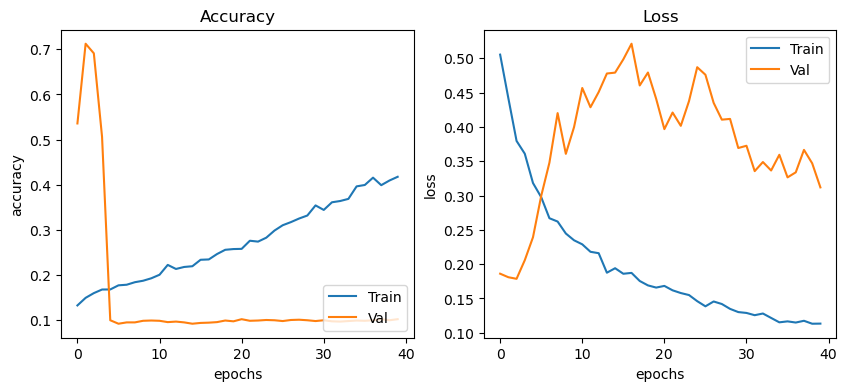

In [57]:
figpath=output_path+"{}".format(savedfilename)+".pdf"
fig = plt.figure(figsize=(10,4))
epochs_range = range(len(history.history['loss']))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Train')
plt.plot(epochs_range, history.history['val_accuracy'], label='Val')
plt.legend(loc='lower right')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Train')
plt.plot(epochs_range, history.history['val_loss'], label='Val')
plt.legend(loc='upper right')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()
fig.savefig(figpath, format='pdf', bbox_inches='tight')

# Predictions

In [58]:
# predictions=model.predict(test_dataset)
# y_pred = np.argmax(predictions, axis=1)
# y_true = np.concatenate([y for x, y in test_dataset], axis=0)
# y_prob = predictions

# same = 0
# total = len(y_true)

# for i in range(total):
#     if y_true[i] == y_pred[i]:
#         same=same+1

# test_acc = same/total*100
# res='{:.2f}'.format(test_acc)
# print(same)
# print(total)
# print(res)

In [59]:
%%time
predi=model.predict(test_ds)
y_p = np.argmax(predi, axis=1)
y_t = np.concatenate([y for x, y in test_ds], axis=0)
y_tt = np.argmax(y_t, axis=1)
y_pr = predi

same = 0
total = len(y_tt)

for i in range(total):
    if y_tt[i] == y_p[i]:
        same=same+1

test_acc = same/total*100
res='{:.2f}'.format(test_acc)
print(same)
print(total)
print(res)

27/27 [==============================] - 3s 63ms/step
1206
1693
71.23
CPU times: user 51.3 s, sys: 660 ms, total: 51.9 s
Wall time: 4.03 s


In [60]:
y_pred = y_p
y_true = y_tt
y_prob = y_pr

In [61]:
%%time
tm = []
correctly_classified = {"y_true":[], "y_pred":[], "y_prob":[], "filename":[], "inference_time":[]}
mis_classified = {"orig":[],"pred":[], "prob":[], "filename":[], "inference_time":[]}
for i in file_names_test:
    image=tf.keras.utils.load_img(i)
    input_arr=tf.keras.utils.img_to_array(image)
    img_resized=tf.image.resize(input_arr, size=(IMG_SIZE, IMG_SIZE))
    input_img=np.array([img_resized])
    start_time=time.time()
    predictions=model(input_img, training=False)
    end_time=time.time()
    t=1000*(end_time-start_time)
    tm.append(t)
    pr_fnl = np.argmax(predictions, axis=1)[0]
    lbl=classes.index(i.split('/')[-2])

    if lbl == pr_fnl:
        correctly_classified["y_true"].append(lbl)
        correctly_classified["y_pred"].append(pr_fnl)
        correctly_classified["y_prob"].append(predictions)
        correctly_classified["filename"].append(i)
        correctly_classified["inference_time"].append(t)
    else:
        mis_classified["orig"].append(lbl)
        mis_classified["pred"].append(pr_fnl)
        mis_classified["prob"].append(predictions)
        mis_classified["filename"].append(i)
        mis_classified["inference_time"].append(t)

print(len(correctly_classified["y_true"]))
print(len(y_t))
test_acc1 = len(correctly_classified["y_true"])/len(y_t)*100
print('{:.2f}'.format(test_acc1))

1202
1693
71.00
CPU times: user 4min 18s, sys: 784 ms, total: 4min 19s
Wall time: 4min 18s


In [62]:
# print(f"Average (ms) : {np.mean(tm)}")
# print(f"Std dev (ms) : {np.std(tm)}")
# print(f"Min     (ms) : {np.min(tm)}")
# print(f"Max     (ms) : {np.max(tm)}")

In [63]:
df11 = pd.DataFrame.from_dict(correctly_classified)
df11.to_csv(output_path+'correctly_classified.csv', index = True, header=True)

df22 = pd.DataFrame.from_dict(mis_classified)
df22.to_csv(output_path+'mis_classified.csv', index = True, header=True)

In [64]:
# y_pred1=correctly_classified["y_pred"]
# y_true1=correctly_classified["y_true"]
# y_prob1=correctly_classified["y_prob"]

# y_pred2=mis_classified["pred"]
# y_true2=mis_classified["orig"]
# y_prob2=mis_classified["prob"]

# y_pred=y_pred1+y_pred2
# y_true=y_true1+y_true2
# y_prob=y_prob1+y_prob2

In [65]:
y_test = tf.keras.utils.to_categorical(y_true)

In [66]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_true, y_pred)
print('Confusion Matrix\n')
print(confusion)

Confusion Matrix

[[   0    0    1    0    0   43    0]
 [   0    0    0    0    0   73    0]
 [   0    0    0    0    0  168    0]
 [   0    0    0    0    0   13    0]
 [   0    0    2    0    0  169    0]
 [   0    0    1    0    0 1206    0]
 [   0    0    1    0    0   16    0]]


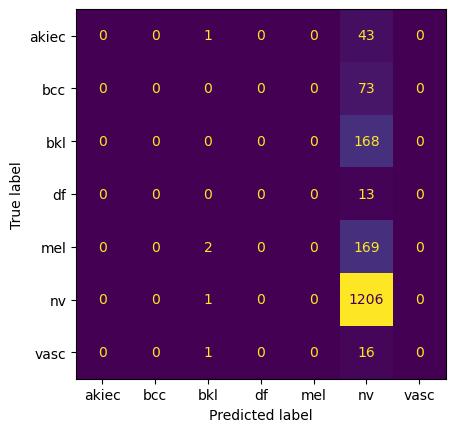

In [67]:
fig_path=output_path+"confusion_matrix.pdf"
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion, display_labels=classes).plot(colorbar=False)
fig=cm_display.figure_
fig.savefig(fig_path, format='pdf', bbox_inches='tight')

In [68]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_true, y_pred, normalize='all')
print('Confusion Matrix\n')
print(confusion)

Confusion Matrix

[[0.00000000e+00 0.00000000e+00 5.90667454e-04 0.00000000e+00
  0.00000000e+00 2.53987005e-02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 4.31187242e-02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 9.92321323e-02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 7.67867690e-03 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.18133491e-03 0.00000000e+00
  0.00000000e+00 9.98227998e-02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 5.90667454e-04 0.00000000e+00
  0.00000000e+00 7.12344950e-01 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 5.90667454e-04 0.00000000e+00
  0.00000000e+00 9.45067927e-03 0.00000000e+00]]


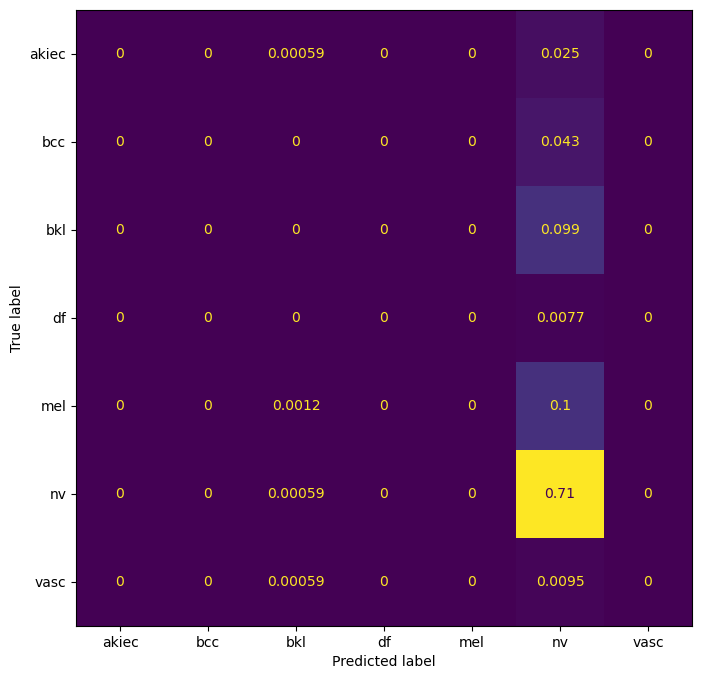

In [69]:
fig_path=output_path+"confusion_matrix1.pdf"
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion, display_labels=classes).plot(colorbar=False)
fig=cm_display.figure_
fig.set_figwidth(8)
fig.set_figheight(8)
fig.savefig(fig_path, format='pdf', bbox_inches='tight')

In [70]:
y_prob = np.array(y_prob)
y_prob_new = y_prob.reshape(y_pr.shape)

In [71]:
from sklearn.metrics import roc_auc_score
targetnames=classes
fpr = {}
tpr = {}
roc_auc = {}
for i in range(num_classes):
    r = roc_auc_score(y_test[:, i], y_prob_new[:, i])
    print("The ROC AUC score of "+targetnames[i]+" is: "+str(r))

The ROC AUC score of akiec is: 0.6256960141132367
The ROC AUC score of bcc is: 0.5102486047691527
The ROC AUC score of bkl is: 0.42368852459016393
The ROC AUC score of df is: 0.5783424908424908
The ROC AUC score of mel is: 0.600871429559444
The ROC AUC score of nv is: 0.6201922257339729
The ROC AUC score of vasc is: 0.44928400954653935


In [72]:
from sklearn.metrics import roc_curve, auc
fpr = {}
tpr = {}
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_prob_new[:, i], drop_intermediate=False)
    roc_auc[i] = auc(fpr[i], tpr[i])

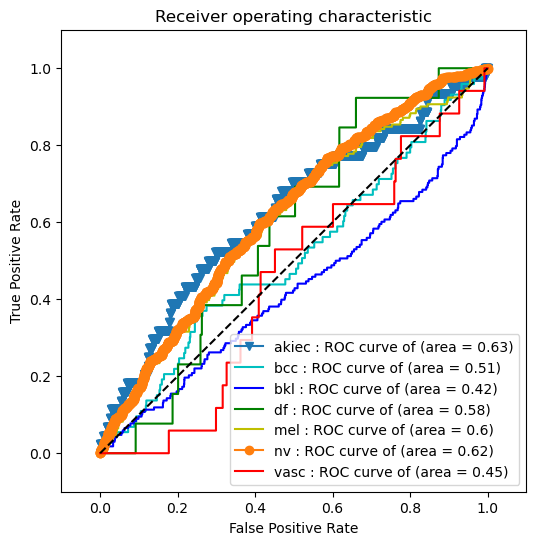

In [73]:
fig_path_roc=output_path+"roc_auc_curve.pdf"
fig = plt.figure(figsize=(6,6))
l0="{}".format(targetnames[0])+" : ROC curve of (area = {}".format(round(roc_auc[0],2))+")"
l1="{}".format(targetnames[1])+" : ROC curve of (area = {}".format(round(roc_auc[1],2))+")"
l2="{}".format(targetnames[2])+" : ROC curve of (area = {}".format(round(roc_auc[2],2))+")"
l3="{}".format(targetnames[3])+" : ROC curve of (area = {}".format(round(roc_auc[3],2))+")"
l4="{}".format(targetnames[4])+" : ROC curve of (area = {}".format(round(roc_auc[4],2))+")"
l5="{}".format(targetnames[5])+" : ROC curve of (area = {}".format(round(roc_auc[5],2))+")"
l6="{}".format(targetnames[6])+" : ROC curve of (area = {}".format(round(roc_auc[6],2))+")"
# l7="{}".format(targetnames[7])+" : ROC curve of (area = {}".format(round(roc_auc[7],2))+")"
# l8="{}".format(targetnames[8])+" : ROC curve of (area = {}".format(round(roc_auc[8],2))+")"
plt.plot(fpr[0], tpr[0],'v-',label=l0)
plt.plot(fpr[1], tpr[1],'c' ,label=l1)
plt.plot(fpr[2], tpr[2],'b' ,label=l2)
plt.plot(fpr[3], tpr[3],'g' ,label=l3)
plt.plot(fpr[4], tpr[4],'y' ,label=l4)
plt.plot(fpr[5], tpr[5],'o-',label=l5)
plt.plot(fpr[6], tpr[6],'r' ,label=l6)
# plt.plot(fpr[7], tpr[7],'o' ,label=l7)
# plt.plot(fpr[8], tpr[8],'c' ,label=l8)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()
fig.savefig(fig_path_roc, format='pdf', bbox_inches='tight')

In [74]:
from sklearn.metrics import accuracy_score
accuracy_score = accuracy_score(y_true, y_pred)
print('Accuracy: {}'.format(accuracy_score))

Accuracy: 0.7123449497932663


In [75]:
from sklearn.metrics import classification_report
classification_report = classification_report(y_true, y_pred,
    target_names=targetnames, zero_division=0)
print('Classification Report : \n')
print(classification_report)

Classification Report : 

              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        44
         bcc       0.00      0.00      0.00        73
         bkl       0.00      0.00      0.00       168
          df       0.00      0.00      0.00        13
         mel       0.00      0.00      0.00       171
          nv       0.71      1.00      0.83      1207
        vasc       0.00      0.00      0.00        17

    accuracy                           0.71      1693
   macro avg       0.10      0.14      0.12      1693
weighted avg       0.51      0.71      0.59      1693



In [76]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [77]:
micro_precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
weighted_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Micro Precision: {micro_precision}")
print(f"Macro Precision: {macro_precision}")
print(f"Weighted Precision: {weighted_precision}")

Micro Precision: 0.7123449497932663
Macro Precision: 0.10206499661475965
Weighted Precision: 0.5093603995263463


In [78]:
micro_recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
weighted_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Micro Recall: {micro_recall}")
print(f"Macro Recall: {macro_recall}")
print(f"Weighted Recall: {weighted_recall}")

Micro Recall: 0.7123449497932663
Macro Recall: 0.14273878565510711
Weighted Recall: 0.7123449497932663


In [79]:
micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Micro F1: {micro_f1}")
print(f"Macro F1: {macro_f1}")
print(f"Weighted F1: {weighted_f1}")

Micro F1: 0.7123449497932663
Macro F1: 0.11902294596595116
Weighted F1: 0.5939898821419499


In [80]:
from sklearn.metrics import roc_auc_score
micro_roc_auc_ovr = roc_auc_score(y_test, y_prob_new, multi_class="ovr",average="micro")
macro_roc_auc_ovr = roc_auc_score(y_test, y_prob_new, multi_class="ovr",average="macro")
weighted_roc_auc_ovr = roc_auc_score(y_true, y_prob_new, multi_class='ovr',average='weighted')

print(f"Micro-averaged One-vs-Rest ROC AUC score: {micro_roc_auc_ovr}")
print(f"Macro-averaged One-vs-Rest ROC AUC score: {macro_roc_auc_ovr}")
print(f"Weighted One-vs-Rest ROC AUC score: {weighted_roc_auc_ovr}")

Micro-averaged One-vs-Rest ROC AUC score: 0.8405922979243372
Macro-averaged One-vs-Rest ROC AUC score: 0.5440461855935714
Weighted One-vs-Rest ROC AUC score: 0.5921061762310051


In [81]:
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy_score = balanced_accuracy_score(y_true, y_pred)
print('balanced_accuracy_score : ', balanced_accuracy_score)

balanced_accuracy_score :  0.14273878565510711


In [82]:
from sklearn.metrics import jaccard_score
jaccard_score = jaccard_score(y_true, y_pred, average='weighted')
print('jaccard_score : ', jaccard_score)

jaccard_score :  0.5090588243934119


In [83]:
specificity = []
cm = np.array(confusion_matrix(y_true, y_pred))
for i in range(cm.shape[0]):
    tn = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
    fp = np.sum(cm[:, i]) - cm[i, i]
    specificity_i = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificity_i = np.round(specificity_i, 6)
    specificity.append(specificity_i)

print(f'Specificity for each class: {specificity}')
spec_unweighted=np.round(np.average(specificity), 6)
spec_weighted=np.round(np.average(specificity, weights=list(classWeight_dict.values())), 6)
print(spec_unweighted)
print(spec_weighted)

Specificity for each class: [1.0, 1.0, 0.996721, 1.0, 1.0, 0.00823, 1.0]
0.85785
0.995239


In [84]:
from sklearn.metrics import multilabel_confusion_matrix
multilabel_confusion_matrix = multilabel_confusion_matrix(y_true, y_pred)
print('multilabel_confusion_matrix : \n', multilabel_confusion_matrix)

multilabel_confusion_matrix : 
 [[[1649    0]
  [  44    0]]

 [[1620    0]
  [  73    0]]

 [[1520    5]
  [ 168    0]]

 [[1680    0]
  [  13    0]]

 [[1522    0]
  [ 171    0]]

 [[   4  482]
  [   1 1206]]

 [[1676    0]
  [  17    0]]]


# Saving All Results

In [85]:
import pandas as pd
Labels={'File_Name':[],'True_Label':[],'Predicted_Label':[],'Prediction_Probability':[]}

for i in range(len(file_names_test)):
    Labels['File_Name'].append(file_names_test[i])
    Labels['True_Label'].append(y_true[i])
    Labels['Predicted_Label'].append(y_pred[i])
    Labels['Prediction_Probability'].append(y_prob_new[i])

df = pd.DataFrame.from_dict(Labels)
df.to_csv(output_path+'Labels.csv', index = False, header=True)

In [86]:
Class_Weights = {'classWeight' : classWeight}
df = pd.DataFrame.from_dict(Class_Weights)
df.to_csv(output_path+'Class_Weights.csv', index = True, header=True)

In [87]:
Hist = {'hist' : history.history}
df = pd.DataFrame.from_dict(Hist)
df.to_csv(output_path+'Hist.csv', index = True, header=True)

In [88]:
Hyperparameters = {
    'Number_of_Classes' : num_classes,
    'Number_of_Train_Images' : num_train_images,
    'Number_of_Test_Images' : num_test_images,
    'BATCH_SIZE' : BATCH_SIZE,
    'IMG_SIZE' : IMG_SIZE,
    'LEARNING_RATE' : LEARNING_RATE,
    'EPOCHS' : EPOCHS,
    'Number_of_Epoch_Actually_Executed' : len(history.history['loss']),
}
df = pd.DataFrame.from_records([Hyperparameters]).transpose()
df.to_csv(output_path+'Hyperparameters.csv', index = True, header=False)

In [89]:
Results_in_Program = {
    'Time_Taken_for_execution_(in_seconds)' : time_taken,
    'Test_Accuracy_by_Model_Evaluate_Method' : test_accuracy_by_evaluate,
    'Number_of_Correct_Predictions' : same,
    'Number_of_Total_Predictions' : total,
    'Test_Accuracy_by_Manual_Matching' : test_acc,
    'Test_Accuracy_Result_Adjusted' : res
}
df = pd.DataFrame.from_records([Results_in_Program]).transpose()
df.to_csv(output_path+'Results_in_Program.csv', index = True, header=False)

In [90]:
Results = {
    'accuracy_score' : accuracy_score,
    'balanced_accuracy_score' : balanced_accuracy_score,
    'jaccard_score' : jaccard_score,

    'micro_precision':micro_precision,
    'macro_precision':macro_precision,
    'weighted_precision':weighted_precision,

    'micro_recall':micro_recall,
    'macro_recall':macro_recall,
    'weighted_recall':weighted_recall,

    'micro_f1':micro_f1,
    'macro_f1':macro_f1,
    'weighted_f1':weighted_f1,

    'micro_roc_auc_ovr': micro_roc_auc_ovr,
    'macro_roc_auc_ovr': macro_roc_auc_ovr,
    'weighted_roc_auc_ovr':weighted_roc_auc_ovr,

    'multilabel_confusion_matrix' : multilabel_confusion_matrix,
}
df = pd.DataFrame.from_records([Results]).transpose()
df.to_csv(output_path+'Results.csv', index = True, header=False)

In [91]:
classification_report = {'classification_report' : classification_report}
df = pd.DataFrame.from_records([classification_report]).transpose()
df.to_csv(output_path+'classification_report.csv', index = True, header=False)

In [92]:
Model_Name = model.name
Input_Shape = model.input_shape
Top_Layer_Dropout_Rate = dropout_rate
Model_Loss = type(model.loss)
Model_Optimizer = type(model.optimizer)
Model_Metrics_Names = model.metrics_names
Model_Metrics = model.metrics
Model_Trainable_Parameters_Count = trainable_count
Model_Non_Trainable_Parameters_Count = non_trainable_count
Model_Total_Parameters_Count = total_count
Model_Output_Shape = model.output_shape

Model_Parameters = {
    'Model_Name' : Model_Name,
    'Input_Shape' : Input_Shape,
    'Top_Layer_Dropout_Rate' : Top_Layer_Dropout_Rate,
    'Model_Loss' : Model_Loss,
    'Model_Optimizer' : Model_Optimizer,
    'LEARNING_RATE' : LEARNING_RATE,
    'Model_Metrics_Names' : Model_Metrics_Names,
    'Model_Metrics' : Model_Metrics,
    'Model_Trainable_Parameters_Count' : Model_Trainable_Parameters_Count,
    'Model_Non_Trainable_Parameters_Count' : Model_Non_Trainable_Parameters_Count,
    'Model_Total_Parameters_Count' : Model_Total_Parameters_Count,
    'Model_Output_Shape' : Model_Output_Shape
}
df = pd.DataFrame.from_records([Model_Parameters]).transpose()
df.to_csv(output_path+'Model_Parameters.csv', index = True, header=False)

# GradCAM

In [93]:
for im, lb in test_ds.take(1):
    sample_test_img = im.numpy()
    sample_test_lbl = lb.numpy()

In [94]:
img_idx=np.random.randint(sample_test_img.shape[0])

In [95]:
sa_model = tf.keras.models.Model(model.inputs,model.get_layer('spatial_attention').output)
sa_maps = sa_model.predict(sample_test_img)

2/2 [==============================] - 2s 25ms/step


In [96]:
sum_attnmap = np.sum(sa_maps[img_idx],2)
sum_attnmap.shape

(7, 7)

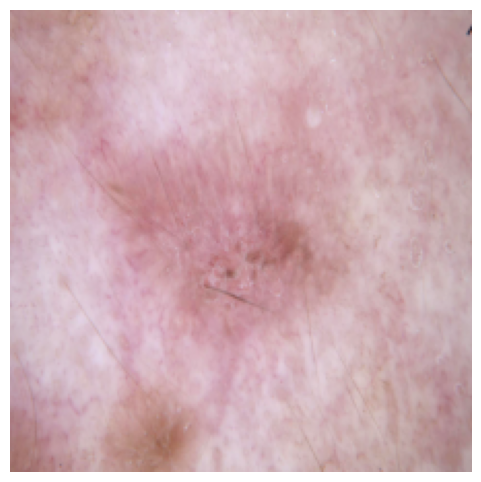

In [97]:
%matplotlib inline
fig_test_img=output_path+'fig_test_img.pdf'
fig=plt.figure(figsize=(6,6))
imgplot=plt.imshow(sample_test_img[img_idx].astype('uint8'))
plt.axis('off')
plt.show()
fig.savefig(fig_test_img, format='pdf', bbox_inches='tight')

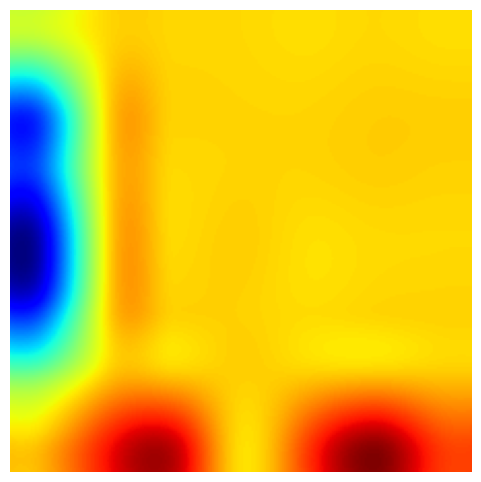

In [98]:
fig_heatmap=output_path+'fig_heatmap.pdf'
fig=plt.figure(figsize=(6,6))
#plt.imshow(sample_test_img[img_idx].astype('uint8'),alpha=1.0)
plt.imshow(cv2.resize(sum_attnmap,(IMG_SIZE,IMG_SIZE),interpolation=cv2.INTER_CUBIC),cmap='jet',alpha=1.0)
plt.axis('off')
plt.show()
fig.savefig(fig_heatmap, format='pdf', bbox_inches='tight')

# Model Plot

In [99]:
tf.keras.utils.plot_model(model, to_file=output_path+'model.pdf',
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=True,
    dpi=1200,
    layer_range=None,
    show_layer_activations=True,
)

# Move temp to saved_models

In [100]:
from pytz import timezone
from datetime import datetime
cur_time=datetime.now(timezone("Asia/Kolkata")).strftime('%d-%m-%Y-%H-%M-%S')
name = cur_time #+ '_' + savedfilename + end
os.rename(tempfolder, name)
source = '{}'.format(name)+'/'
dest=shutil.move(source, destination)

In [101]:
print(dest)

Results/classification2/1.HAM10000/Fold1/22-08-2025-19-13-26
